Tutorial para visualizar señales electrofisiológicas con la opción de enfocar segmentos específicos mediante una función de zoom.

En este caso trabajaremos con el procesamiento de señales de EMG (electromiograma). Una señal de EMG es una medida de la actividad eléctrica producida por músculos al contraerse. De esta manera se puede capturar la actividad neuromuscular del cuerpo, con el uso potencial de diagnosticar la salud del músculo y desórdenes neurológicos.

Para realizar electromiogramas se colocan tres electrodos de la siguiente manera: 2 en el músculo de interés con el objetivo de captar la actividad eléctrica y otro alejado de la zona de interés, que toma el papel de tierra. Existen dos tipos de electrodos que alcanzan objetivos distintos: los electrodos de superficie permiten realizar registros rápidos de áreas grandes, pero suelen capturar más ruido, mientras que los electrodos de aguja permiten un enfoque más focalizado y con menos ruido, con la desventaja de ser más invasivos.

En esta práctica utilizamos el hardware Spikerbox de Backyard Brains con el software provisto por el fabricante. Colocamos los electrodos en el área de interés y contraemos el músculo múltiples veces para observar la actividad en el registro. Es importante revisar que la caja tenga batería y poner atención a no desconectar los electrodos de la piel cuando el spikerbox esté encendido, esto produce un sonido fuerte que puede dañar el amplificador.

Posteriormente el registro se guarda como archivo wav, el cual podemos visualizar con el código siguiente.

In [ ]:
# comando para poder ver gráficos en el
%matplotlib widget


# import plotting module
import matplotlib.pyplot as plt

In [2]:
import math
import numpy as np
import scipy as sc
import wave
import ipywidgets as widgets
from scipy import signal
from scipy.io import wavfile
from scipy.signal import butter, lfilter, filtfilt
from ipywidgets import interact, interactive, fixed, interact_manual
from matplotlib.widgets import SpanSelector, Slider, Button
from IPython.display import display
from statsmodels.distributions.empirical_distribution import ECDF

In [ ]:
def EMG(file):
    # abrir el archivo wav
    record = wave.open(file)
    # extraer el número de canales, la tasa de muestreo y los datos
    numChannels = record.getnchannels() 
    N = record.getnframes() 
    sampleRate = record.getframerate()
    
    dstr = record.readframes(N * numChannels)
    waveData = np.frombuffer(dstr, np.int16)
    # imprimir el número de canales y la tasa de muestreo
    print('The recording has %d channel(s).' % (numChannels))
    print('The sampling rate of the recording is %d Hz.' % (sampleRate))
    # calcular el tiempo transcurrido
    timeEMG=np.linspace(0, len(waveData)/sampleRate, num=len(waveData))
    # calcular las frecuencias presentes
    freq = 1/np.mean(np.diff(timeEMG))

      # guardar la información relevante en un arreglo
    xx={'sampleRate':sampleRate,\
        'waveData':waveData,\
        'timeEMG':timeEMG,\
        'freq':freq}
    
    # Graficar la señal e implementar un widget que permita hacer zoom a las partes de mayor interés
    fig, (ax1,ax2) = plt.subplots(2,figsize=(12,6))
    ax1.plot(timeEMG,waveData, 'b')
    ax1.set_ylabel(r'voltage ($\mu$V)')
    fig.suptitle('Gráfica interactiva de la onda EMG')

    
    line2, = ax2.plot(timeEMG, waveData, 'b')
    ax2.set_xlabel(r'time (s)')
    ax2.set_ylabel(r'voltage ($\mu$V)')

    # La función onselect junto con el SpanSelector se encargan de actualizar la gráfica con los límites horizontales seleccionados sobre la gráfica
    # El zoom ajusta los límites de graficación sobre X, de manera que permite enfocarse en un pico o algún otro punto de interés
    def onselect(xmin, xmax):
        indmin, indmax = np.searchsorted(timeEMG, (xmin, xmax))
        indmax = min(len(timeEMG) - 1, indmax)

        thisx = timeEMG[indmin:indmax]
        thisy = waveData[indmin:indmax]
        line2.set_data(thisx, thisy)
        ax2.set_xlim(thisx[0], thisx[-1])
        ax2.set_ylim(thisy.min(), thisy.max())
        fig.canvas.draw()
        print(f'The selected range is ({xmin}, {xmax})')

    span = SpanSelector(ax1, onselect, 'horizontal', useblit=True,
                        props=dict(alpha=0.5, facecolor='red'))


    
    plt.show()
    return xx

The recording has 1 channel(s).
The sampling rate of the recording is 44100 Hz.


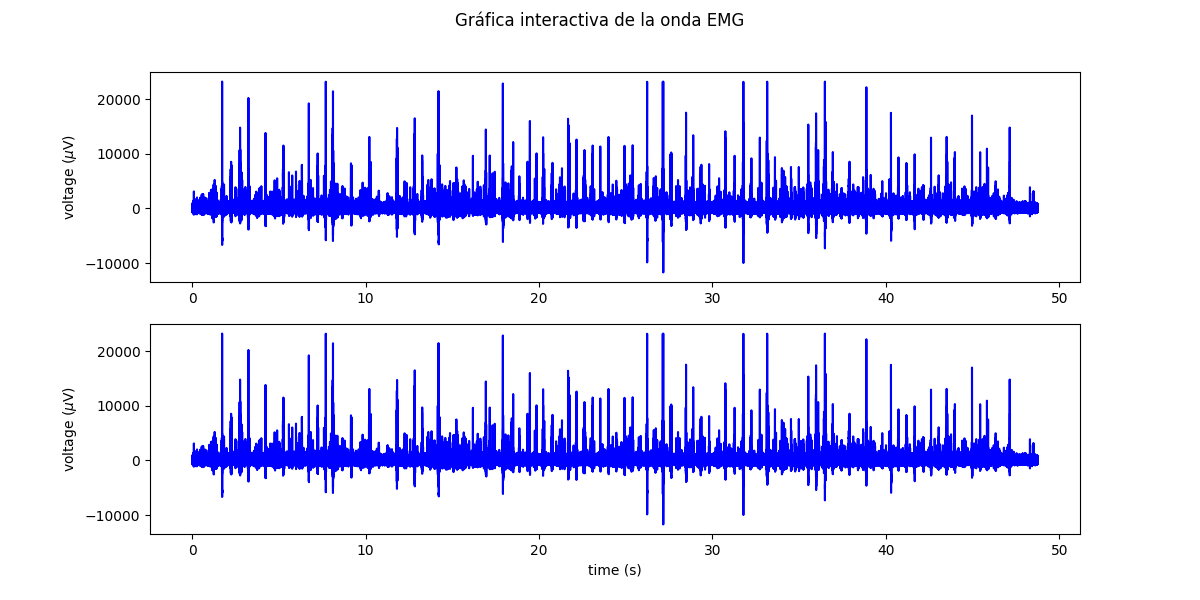

In [ ]:
longbiceps = '/Users/pipeavina/Downloads/RegistroFlexoresLateralMedialLuis.wav' # Coloca el path del archivo wav que desees visualizar
xx = EMG(longbiceps)